In [1]:
#showing head of the original csv

import pandas as pd
from pathlib import Path
import h3
import numpy as np


In [2]:
PROJECT    = Path(r"E:/tfl_project")
OUT_DIR    = PROJECT / "outputs"

In [2]:
weekly_csv = pd.read_csv("data\\01aJourneyDataExtract10Jan16-23Jan16.csv")

In [3]:
weekly_csv.head()

,Rental Id,Duration,Bike Id,End Date,EndStation Id,EndStation Name,Start Date,StartStation Id,StartStation Name
0,50754225,240,11834,10/01/2016 00:04,383.0,"Frith Street, Soho",10/01/2016 00:00,18,"Drury Lane, Covent Garden"
1,50754226,300,9648,10/01/2016 00:05,719.0,"Victoria Park Road, Hackney Central",10/01/2016 00:00,479,"Pott Street, Bethnal Green"
2,50754227,1200,10689,10/01/2016 00:20,272.0,"Baylis Road, Waterloo",10/01/2016 00:00,425,"Harrington Square 2, Camden Town"
3,50754228,780,8593,10/01/2016 00:14,471.0,"Hewison Street, Old Ford",10/01/2016 00:01,487,"Canton Street, Poplar"
4,50754229,600,8619,10/01/2016 00:11,399.0,"Brick Lane Market, Shoreditch",10/01/2016 00:01,501,"Cephas Street, Bethnal Green"


In [5]:
# Show just the columns that tell the story
cols_to_show = [
 #   "Rental Id",
    "Start Date",
  #  "StartStation Id", 
    "StartStation Name",
    "End Date",
    "EndStation Name",
    "Duration",
]

sample = weekly_csv[cols_to_show].head(5)

# For a Jupyter notebook — renders as a clean HTML table
sample.style.hide(axis="index")

# For copying into a Medium/TDS article — export as markdown
print(sample.to_markdown(index=False))

# For a screenshot — set display options first
pd.set_option("display.max_colwidth", 30)
pd.set_option("display.width", 120)
print(sample.to_string(index=False))

| Start Date       | StartStation Name                | End Date         | EndStation Name                     |   Duration |
|:-----------------|:---------------------------------|:-----------------|:------------------------------------|-----------:|
| 10/01/2016 00:00 | Drury Lane, Covent Garden        | 10/01/2016 00:04 | Frith Street, Soho                  |        240 |
| 10/01/2016 00:00 | Pott Street, Bethnal Green       | 10/01/2016 00:05 | Victoria Park Road, Hackney Central |        300 |
| 10/01/2016 00:00 | Harrington Square 2, Camden Town | 10/01/2016 00:20 | Baylis Road, Waterloo               |       1200 |
| 10/01/2016 00:01 | Canton Street, Poplar            | 10/01/2016 00:14 | Hewison Street, Old Ford            |        780 |
| 10/01/2016 00:01 | Cephas Street, Bethnal Green     | 10/01/2016 00:11 | Brick Lane Market, Shoreditch       |        600 |
      Start Date                StartStation Name         End Date                     EndStation Name  Duration
10/01

In [ ]:
base = pd.read_parquet(OUT_DIR / "base_combined.parquet")

In [10]:
base_head =base.head()

base_head.style.hide(axis="index")

# For copying into a Medium/TDS article — export as markdown
print(base_head.to_markdown(index=False))

|   station_id | trips_start         |   ts |
|-------------:|:--------------------|-----:|
|            1 | 2016-01-10 09:00:00 |    4 |
|            1 | 2016-01-10 10:00:00 |    1 |
|            1 | 2016-01-10 11:00:00 |    2 |
|            1 | 2016-01-10 12:00:00 |    2 |
|            1 | 2016-01-10 13:00:00 |    2 |


In [3]:
base.shape

(9671772, 3)

naive treatment effect, calculated on original data

In [3]:
bf = pd.read_parquet(OUT_DIR / "bike_hourly_with_covariates.parquet")

# Process in chunks to avoid memory spike
chunk_size = 100_000
h3_cells = []
for i in range(0, len(bf), chunk_size):
    chunk = bf.iloc[i:i+chunk_size]
    h3_cells.extend([h3.latlng_to_cell(lat, lon, 8) for lat, lon in zip(chunk["lat"], chunk["lon"])])
    print(f"  Processed {min(i+chunk_size, len(bf)):,} / {len(bf):,}")

bf["h3_cell"] = h3_cells

# Aggregate to cell-day
bf["day"] = pd.to_datetime(bf["trips_start"]).dt.date

cell_day = (
    bf.groupby(["h3_cell", "day"])
    .agg(
        total_trips           = ("ts", "sum"),
        frac_exposed          = ("strike_exposed", "mean"),
        n_stations            = ("station_id", "nunique"),
        temperature_2m        = ("temperature_2m", "mean"),
        precipitation         = ("precipitation", "mean"),
        cloud_cover           = ("cloud_cover", "mean"),
        wind_speed_10m        = ("wind_speed_10m", "mean"),
        is_weekend            = ("is_weekend", "first"),
        is_am_peak            = ("is_am_peak", "first"),
        is_pm_peak            = ("is_pm_peak", "first"),
        is_bank_holiday       = ("is_bank_holiday", "first"),
        is_school_holiday     = ("is_school_holiday", "first"),
        strike_severity_daily_frac = ("strike_severity_daily_frac", "first"),
        days_to_next_strike   = ("days_to_next_strike", "first"),
        days_since_last_strike= ("days_since_last_strike", "first"),
        month                 = ("month", "first"),
        year                  = ("year", "first"),
        doy                   = ("doy", "first"),
        lat                   = ("lat", "mean"),
        lon                   = ("lon", "mean"),
    )
    .reset_index()
)

cell_day["day"]              = pd.to_datetime(cell_day["day"])
cell_day["y_per_station_log1p"] = np.log1p(cell_day["total_trips"] / cell_day["n_stations"])
cell_day["treated"]          = (cell_day["frac_exposed"] > 0).astype(int)

  Processed 100,000 / 9,206,267
  Processed 200,000 / 9,206,267
  Processed 300,000 / 9,206,267
  Processed 400,000 / 9,206,267
  Processed 500,000 / 9,206,267
  Processed 600,000 / 9,206,267
  Processed 700,000 / 9,206,267
  Processed 800,000 / 9,206,267
  Processed 900,000 / 9,206,267
  Processed 1,000,000 / 9,206,267
  Processed 1,100,000 / 9,206,267
  Processed 1,200,000 / 9,206,267
  Processed 1,300,000 / 9,206,267
  Processed 1,400,000 / 9,206,267
  Processed 1,500,000 / 9,206,267
  Processed 1,600,000 / 9,206,267
  Processed 1,700,000 / 9,206,267
  Processed 1,800,000 / 9,206,267
  Processed 1,900,000 / 9,206,267
  Processed 2,000,000 / 9,206,267
  Processed 2,100,000 / 9,206,267
  Processed 2,200,000 / 9,206,267
  Processed 2,300,000 / 9,206,267
  Processed 2,400,000 / 9,206,267
  Processed 2,500,000 / 9,206,267
  Processed 2,600,000 / 9,206,267
  Processed 2,700,000 / 9,206,267
  Processed 2,800,000 / 9,206,267
  Processed 2,900,000 / 9,206,267
  Processed 3,000,000 / 9,206,26

In [6]:
print(f"Naive diff   : {np.expm1(cell_day.loc[cell_day['treated']==1,'y_per_station_log1p'].mean() - cell_day.loc[cell_day['treated']==0,'y_per_station_log1p'].mean())*100:+.1f}%")

Naive diff   : +5.5%


Plot illustrating the h3 cells

C:\Users\lukes\AppData\Local\Temp\ipykernel_12956\1900793830.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, loc="upper left", framealpha=0.95, edgecolor="#DDDDDD")


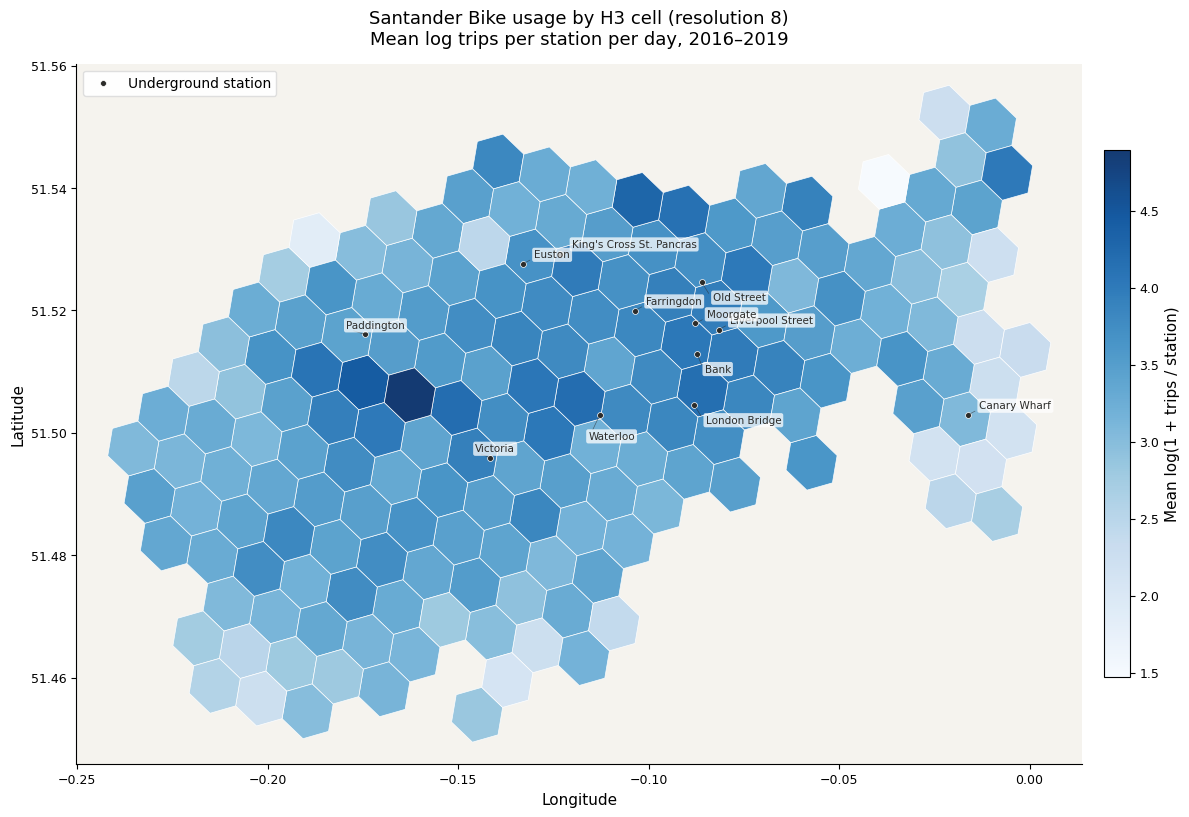

In [12]:
import h3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def hex_vertices(lat, lon, radius_deg=0.0025):
    """Return the six vertices of a pointy-top H3 hex in plot coordinates."""
    verts = []
    for i in range(6):
        angle = np.radians(60 * i - 30)
        verts.append((
            lon + radius_deg * 1.15 * np.cos(angle),
            lat + radius_deg * np.sin(angle),
        ))
    return verts

# ── Compute mean trips per station per cell ───────────────────────────────────
cell_summary = (
    cell_day
    .groupby("h3_cell")["y_per_station_log1p"]
    .mean()
    .reset_index()
    .rename(columns={"y_per_station_log1p": "mean_trips"})
)

# Get centroids from H3 directly (more accurate than averaging station coords)
cell_summary["lat"] = cell_summary["h3_cell"].apply(lambda c: h3.cell_to_latlng(c)[0])
cell_summary["lon"] = cell_summary["h3_cell"].apply(lambda c: h3.cell_to_latlng(c)[1])

# ── Build hex patches ─────────────────────────────────────────────────────────
patches  = []
values   = []

for _, row in cell_summary.iterrows():
    boundary = h3.cell_to_boundary(row["h3_cell"])
    # swap (lat, lon) → (lon, lat) for x/y plotting
    verts = [(lon, lat) for lat, lon in boundary]
    patches.append(Polygon(verts, closed=True))
    values.append(row["mean_trips"])

values = np.array(values)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F5F3EE")

collection = PatchCollection(
    patches,
    cmap       = "Blues",
    linewidths = 0.5,
    edgecolors = "white",
    alpha      = 0.95,
)
collection.set_array(values)
collection.set_clim(values.min(), values.max())
ax.add_collection(collection)



# ── Colourbar ─────────────────────────────────────────────────────────────────
cbar = plt.colorbar(collection, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Mean log(1 + trips / station)", fontsize=11)
cbar.ax.tick_params(labelsize=9)

# ── Fix aspect ratio — critical for correct hex shape ─────────────────────────
# In London (lat ~51.5), one degree of longitude ≈ 0.63 × one degree of latitude
ax.set_aspect(1 / np.cos(np.radians(51.5)))

ax.set_xlim(cell_summary["lon"].min() - 0.015,
            cell_summary["lon"].max() + 0.015)
ax.set_ylim(cell_summary["lat"].min() - 0.008,
            cell_summary["lat"].max() + 0.008)

ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude",  fontsize=11)
ax.set_title(
    "Santander Bike usage by H3 cell (resolution 8)\n"
    "Mean log trips per station per day, 2016–2019",
    fontsize=13, pad=14,
)

#ax.plot([], [], color="#C0392B", linewidth=1.6, label="Central 32 cells (study area)")
ax.legend(fontsize=10, loc="upper left", framealpha=0.95, edgecolor="#DDDDDD")

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9)

# ── Tube station overlay ──────────────────────────────────────────────────────
# Load from the FOI CSV so coordinates match what was used in the analysis
tube_foi = pd.read_csv("Stations_20180921.csv")
tube_lu  = tube_foi[tube_foi["NETWORK"] == "London Underground"].copy()
tube_lu  = tube_lu.rename(columns={"x": "lon", "y": "lat"})

# Filter to stations within the plot extent so labels don't overlap the edges
lon_min, lon_max = cell_summary["lon"].min() - 0.015, cell_summary["lon"].max() + 0.015
lat_min, lat_max = cell_summary["lat"].min() - 0.008, cell_summary["lat"].max() + 0.008

tube_visible = tube_lu[
    tube_lu["lon"].between(lon_min, lon_max) &
    tube_lu["lat"].between(lat_min, lat_max)
].copy()



# Label only the major interchange stations to avoid clutter
major = {
    "Bank",
    "Liverpool Street",
    "King's Cross St. Pancras",
    "Waterloo",
    "Victoria",
    "London Bridge",
    "Paddington",
    "Euston",
    "Canary Wharf",
    "Farringdon",
    "Moorgate",
    "Old Street",
}

label_offsets = {
    "Bank":                     ( 0.002, -0.003),
    "Liverpool Street":         ( 0.003,  0.001),
    "King's Cross St. Pancras": ( 0.003,  0.001),
    "Waterloo":                 (-0.003, -0.004),
    "Victoria":                 (-0.004,  0.001),
    "London Bridge":            ( 0.003, -0.003),
    "Paddington":               (-0.005,  0.001),
    "Euston":                   ( 0.003,  0.001),
    "Canary Wharf":             ( 0.003,  0.001),
    "Farringdon":               ( 0.003,  0.001),
    "Moorgate":                 ( 0.003,  0.001),
    "Old Street":               ( 0.003, -0.003),
}

tube_visible = tube_lu[
    tube_lu["lon"].between(lon_min, lon_max) &
    tube_lu["lat"].between(lat_min, lat_max)
].copy()

#only show the major stations

tube_visible = tube_visible[tube_visible["NAME"].isin(major)]

#remove double paddington
tube_visible = tube_visible[tube_visible["OBJECTID"] != 94]

# Plot all visible stations as small dots
ax.scatter(
    tube_visible["lon"],
    tube_visible["lat"],
    s         = 18,
    color     = "#2C2C2A",
    zorder    = 8,
    linewidths= 0.5,
    edgecolors= "white",
)

for _, row in tube_visible[tube_visible["NAME"].isin(major)].iterrows():
    dx, dy = label_offsets.get(row["NAME"], (0.002, 0.002))
    ax.annotate(
        row["NAME"],
        xy         = (row["lon"], row["lat"]),
        xytext     = (row["lon"] + dx, row["lat"] + dy),
        fontsize   = 7.5,
        fontweight = "500",
        color      = "#2C2C2A",
        zorder     = 9,
        bbox       = dict(
            boxstyle    = "round,pad=0.2",
            facecolor   = "white",
            edgecolor   = "none",
            alpha       = 0.75,
        ),
    )
    # Small line connecting label to dot
    ax.plot(
        [row["lon"], row["lon"] + dx * 0.6],
        [row["lat"], row["lat"] + dy * 0.6],
        color     = "#2C2C2A",
        linewidth = 0.5,
        zorder    = 8,
        alpha     = 0.6,
    )

# Update legend
#ax.plot([], [], color="#C0392B", linewidth=1.6, label="Central 32 cells (study area)")
ax.scatter([], [], s=18, color="#2C2C2A", edgecolors="white",
           linewidths=0.5, label="Underground station")
ax.legend(fontsize=10, loc="upper left", framealpha=0.95, edgecolor="#DDDDDD")

plt.tight_layout()
plt.savefig("h3_cell_map.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

In [11]:
tube_visible

,FID,OBJECTID,NAME,EASTING,NORTHING,LINES,NETWORK,Zone,lon,lat
7,7,85,Liverpool Street,533094,181567,"Metropolitan, Central, Circle, Hammersmith & City",London Underground,1,-0.081601,51.516842
8,8,86,Moorgate,532668,181668,"Metropolitan, Northern, Circle, Hammersmith & ...",London Underground,1,-0.087700,51.517853
10,10,88,Farringdon,531560,181874,"Metropolitan, Circle, Hammersmith & City",London Underground,1,-0.103582,51.519961
11,11,89,King's Cross St. Pancras,530175,182875,"Metropolitan, Northern, Piccadilly, Circle, Vi...",London Underground,1,-0.123168,51.529277
16,16,94,Paddington,526704,181198,"Hammersmith & City, District, Circle, Bakerloo",London Underground,1,-0.173789,51.514995
21,21,110,Victoria,528999,179130,"District, Circle, Victoria",London Underground,1,-0.141485,51.495890
35,35,47,Bank,532710,181120,"Waterloo & City, Northern, Central",London Underground,1,-0.087297,51.512915
40,40,67,Paddington,526659,181314,"Hammersmith & City, District, Circle, Bakerloo",London Underground,1,-0.174388,51.516053
43,43,197,Euston,529498,182668,"Northern, Victoria",London Underground,1,-0.132992,51.527577
44,44,198,Waterloo,530968,179962,"Waterloo & City, Bakerloo, Northern, Jubilee",London Underground,1,-0.112819,51.502914
